In [ ]:
#this notebook is EDA to see if building a predictive model of session length makes sense
#in terms of constructing a heirarchal/stacked model

In [ ]:
#%pip install duckdb


In [22]:
import duckdb
import numpy 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [2]:
con = duckdb.connect('../data/workload.duckdb')
workload = con.execute("""
    SELECT
        media_title,
        video_type,
        video_subtype,
        creation_category,
        date_workflow,
        time_start,
        time_end,
        duration,
        sessions_combined,
        media_type,
        media_series
    FROM combined_sessions
    ORDER BY date_workflow::DATE, time_start
""").df()
con.close()


In [3]:
pd.set_option('display.max_rows', 25)

In [7]:
pd.set_option('display.max_columns', 200)

In [4]:
workload.head()

,media_title,video_type,video_subtype,creation_category,date_workflow,time_start,time_end,duration,sessions_combined,media_type,media_series
0,Elden Ring,Playthrough,Part 5,Script,2023-02-13,10:45:00,11:27:00,31.0,3,Video Games,Soulsborne Games
1,Elden Ring,Playthrough,Part 5,Processing Raw Video,2023-02-13,10:49:00,10:52:00,3.0,1,Video Games,Soulsborne Games
2,Elden Ring,Playthrough,Part 5,Script,2023-02-13,13:17:00,13:51:00,34.0,1,Video Games,Soulsborne Games
3,Elden Ring,Playthrough,Part 5,Recording Audio,2023-02-13,15:46:00,16:18:00,25.0,2,Video Games,Soulsborne Games
4,Elden Ring,Playthrough,Part 5,Script,2023-02-13,23:14:00,23:47:00,33.0,1,Video Games,Soulsborne Games


In [ ]:
#looking at summary statistics for the different creation_categories and their durations
workload.groupby('creation_category')['duration'].agg(['mean','median','std','count'])

,mean,median,std,count
creation_category,,,,
Editing,41.193393,33.0,32.046246,1453
Processing Raw Video,8.142857,5.0,7.984774,28
Recording Audio,23.156028,17.0,21.274275,282
Recording Video,45.687042,37.0,33.553730,409
Script,27.796399,21.0,21.436131,722
Subtitles,29.961538,26.0,19.090271,26
Thumbnail,18.414343,16.0,14.300617,251
Uploading,12.703947,14.0,8.358553,152


In [ ]:
# bin time_start into quarters of the day and see how long i spend depending on those bins
workload['hour_start'] = pd.to_datetime(workload['time_start'], format='%H:%M:%S').dt.hour

workload['day_quarter'] = pd.cut(
    workload['hour_start'],
    bins=[-1, 5, 11, 17, 23],
    labels=['Midnight–5:59 AM', '6:00–11:59 AM', '12:00–5:59 PM', '6:00–11:59 PM']
)

workload.groupby('day_quarter', observed=True)['duration'].agg(['mean', 'median', 'std', 'count'])

,mean,median,std,count
day_quarter,,,,
Midnight–5:59 AM,22.513514,17.0,21.641808,37
6:00–11:59 AM,35.155828,28.0,29.839851,815
12:00–5:59 PM,35.859438,26.0,30.801293,1494
6:00–11:59 PM,30.337769,24.0,25.611348,977


In [15]:
#lets look at the breakdown of creation_category by day_quarter
pd.crosstab(workload['creation_category'], workload['day_quarter'], normalize='columns')

day_quarter,Midnight–5:59 AM,6:00–11:59 AM,12:00–5:59 PM,6:00–11:59 PM
creation_category,,,,
Editing,0.378378,0.446626,0.409639,0.473900
Processing Raw Video,0.000000,0.019632,0.004016,0.006141
Recording Audio,0.000000,0.090798,0.101740,0.057318
Recording Video,0.054054,0.114110,0.143240,0.102354
Script,0.054054,0.211043,0.249665,0.179120
Subtitles,0.000000,0.012270,0.008701,0.003071
Thumbnail,0.324324,0.068712,0.052878,0.106448
Uploading,0.189189,0.036810,0.030120,0.071648


In [20]:
#lets look at the breakdown of creation_category by day_quarter
pd.crosstab(workload['creation_category'], workload['day_quarter'], normalize='index')

day_quarter,Midnight–5:59 AM,6:00–11:59 AM,12:00–5:59 PM,6:00–11:59 PM
creation_category,,,,
Editing,0.009635,0.250516,0.421198,0.318651
Processing Raw Video,0.000000,0.571429,0.214286,0.214286
Recording Audio,0.000000,0.262411,0.539007,0.198582
Recording Video,0.004890,0.227384,0.523227,0.244499
Script,0.002770,0.238227,0.516620,0.242382
Subtitles,0.000000,0.384615,0.500000,0.115385
Thumbnail,0.047809,0.223108,0.314741,0.414343
Uploading,0.046053,0.197368,0.296053,0.460526


In [18]:

# chi-square needs raw counts, not proportions
ct_raw = pd.crosstab(workload['creation_category'], workload['day_quarter'])

chi2, p, dof, expected = chi2_contingency(ct_raw)
print(f"Chi-square: {chi2:.2f}  |  df: {dof}  |  p-value: {p:.4f}")

# standardized residuals show *which* cells are driving the difference
# values outside ±2 are noteworthy, outside ±3 are strong
std_residuals = (ct_raw - expected) / numpy.sqrt(expected)
std_residuals.round(2)

Chi-square: 167.58  |  df: 21  |  p-value: 0.0000


day_quarter,Midnight–5:59 AM,6:00–11:59 AM,12:00–5:59 PM,6:00–11:59 PM
creation_category,,,,
Editing,-0.54,0.40,-1.61,1.73
Processing Raw Video,-0.56,3.49,-1.86,-0.78
Recording Audio,-1.77,0.58,2.24,-2.96
Recording Video,-1.20,-0.73,2.22,-1.85
Script,-2.13,-0.38,2.69,-2.56
Subtitles,-0.54,1.43,0.38,-1.68
Thumbnail,5.51,-0.71,-3.19,3.52
Uploading,4.08,-1.19,-2.82,3.79


In [ ]:
#based on above, seems thumbnail and uploading are the big ones that are weighted towards late in the day
#but those are also the ones that don't take much time.

#so no real juice here when looking at it 

In [ ]:
#however, i suspect that its definitely changing over time. 

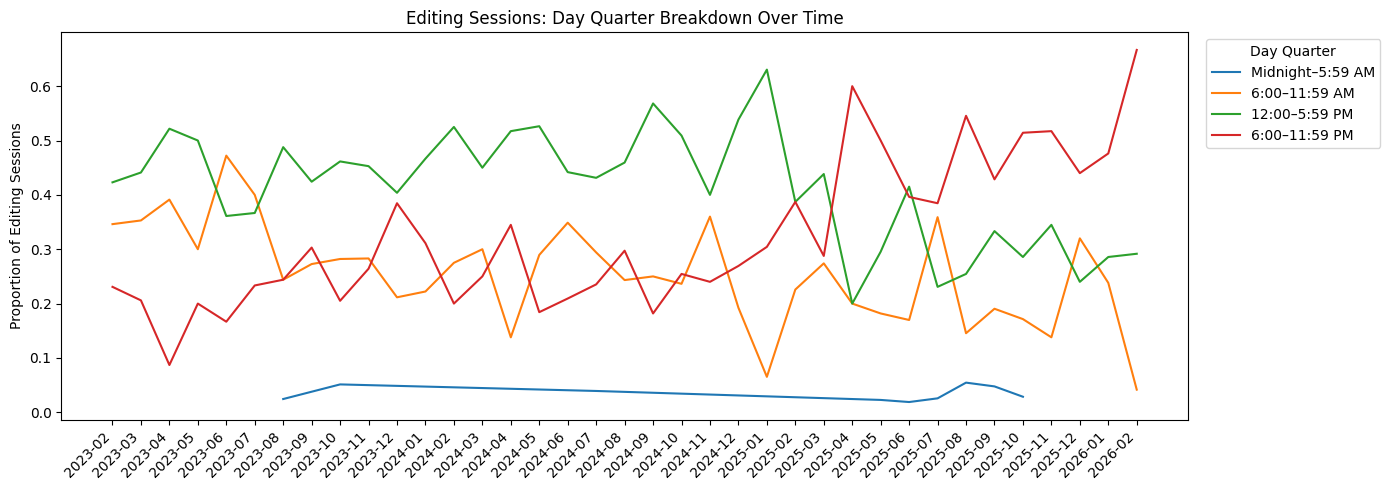

In [23]:
# proportion of Editing sessions in each day_quarter, tracked over time
editing = workload[workload['creation_category'] == 'Editing'].copy()
editing['month_year'] = pd.to_datetime(editing['date_workflow']).dt.to_period('M').astype(str)

ct = (
    editing.groupby(['month_year', 'day_quarter'], observed=True)
    .size()
    .reset_index(name='count')
)
ct['proportion'] = ct.groupby('month_year')['count'].transform(lambda x: x / x.sum())

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=ct, x='month_year', y='proportion', hue='day_quarter', ax=ax)
ax.set_title('Editing Sessions: Day Quarter Breakdown Over Time')
ax.set_xlabel('')
ax.set_ylabel('Proportion of Editing Sessions')
ax.legend(title='Day Quarter', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#i think ill want potentially some moving averages.  Like the average duration time over the last 30 days for each creation_category.